# Introduction to dyadic scales
Fourier transforms use linear frequency intervals; multiresolution methods often use geometric frequency intervals. Inherited from ISO3 and music theory (the 12 equal temperament system has order N=12), standardized fractional octave bands have geometric intervals. When these geometric intervals are base 2 [dyadic], they are a good match to computing systems in general and FFTs in particular.

In [2]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
from quantum_inferno import qi_debugger
import quantum_inferno.scales_dyadic as qi_scales

### Order and harmony
Why choose standardized musical frequencies? So we can all play together. Triads work on all instruments everywhere, and with a standardized tuning to concert A [or any other tuning] large groups of people can make music that sounds pleasing. If the instruments are not tuned, the result will likely be dissonant.

Octaves tones correspond to factors of two in oscillation frequency, and sound harmonious because of their cycle alignment. This is the foundation of music theory and its relation to natural oscillatory systems (such as planetary orbits, tides, etc.), which have sine, cosine, and oscillatory exponential functions as basic building blocks. 

The 12-tone equal temperament system divides the octave into 12 geometric intervals; 12th order bands. In just intonation the major triad frequencies [root, major third, and perfect fifth in the major scale] have proportions 4:5:6 and are acoustically consonant as their harmonics resonate. 

This example add notes [A3, C#4, E4] to constrict a resonant a major triad sinusoid with root at A3 [220 Hz] and proportions 4/4:5/4:6/4. The sample rate is selected to be much higher than the highest tone frequency so that there is no significant aliasing.

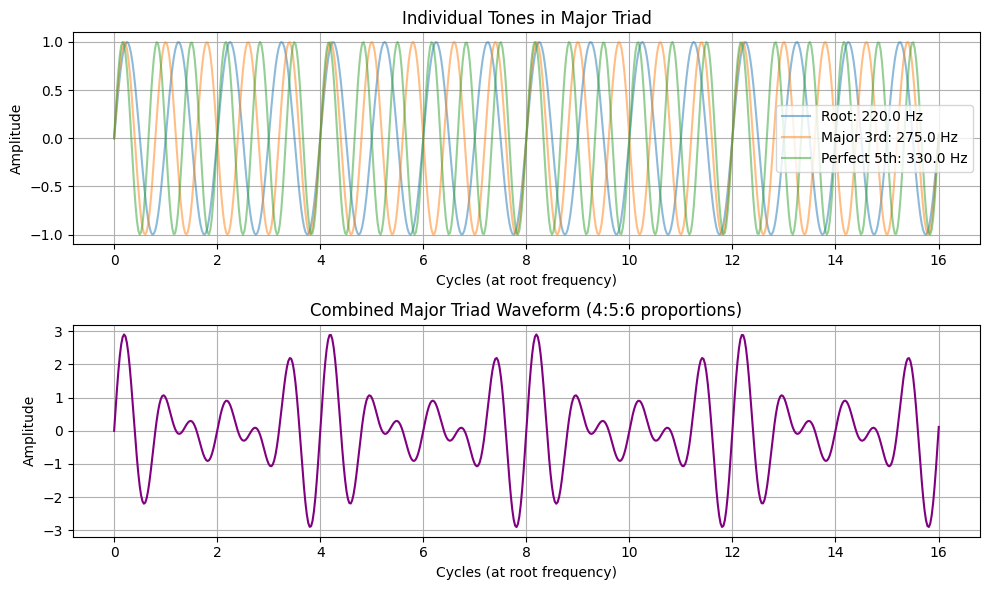

Major triad frequencies:
  Root (R): 220.00 Hz
  Major 3rd: 275.00 Hz
  Perfect 5th: 330.00 Hz
Frequency ratios: 1.0 : 1.25 : 1.50
Ideal ratios: 1.00 : 1.25 : 1.50 (or 4:5:6)


In [ ]:
# Construct a major triad sinusoid with proportions 4:5:6
# Using a base frequency and creating the major third and perfect fifth
f_root = 220.0  # A3 (Hz)
f_major_third = f_root * 5/4  # 275 Hz (C#4)
f_perfect_fifth = f_root * 6/4  # 330 Hz (E4)

# Time array
fs = 8000.0  # Sample rate (Hz)
duration = 2.0  # seconds
t = np.linspace(0, duration, int(fs * duration), endpoint=False)

# Generate the three tones, no harmonics. Sample rate is much higher than tone frequency
tone_root = np.sin(2 * np.pi * f_root * t)
tone_third = np.sin(2 * np.pi * f_major_third * t)
tone_fifth = np.sin(2 * np.pi * f_perfect_fifth * t)

# Combine into major triad (equal amplitude)
major_triad = tone_root + tone_third + tone_fifth

# Convert time to cycles at root frequency
cycles_root = f_root * t

# Plot the waveform (first 16 cycles)
n_cycles = 16
plot_samples = int(n_cycles / f_root * fs) + 2  # +2 to include endpoint
plt.figure(figsize=(10, 6))

plt.subplot(2, 1, 1)
plt.plot(cycles_root[:plot_samples], tone_root[:plot_samples], alpha=0.5, label=f'Root: {f_root:.1f} Hz')
plt.plot(cycles_root[:plot_samples], tone_third[:plot_samples], alpha=0.5, label=f'Major 3rd: {f_major_third:.1f} Hz')
plt.plot(cycles_root[:plot_samples], tone_fifth[:plot_samples], alpha=0.5, label=f'Perfect 5th: {f_perfect_fifth:.1f} Hz')
plt.xlabel('Cycles (at root frequency)')
plt.ylabel('Amplitude')
plt.title('Individual Tones in Major Triad')
plt.legend()
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(cycles_root[:plot_samples], major_triad[:plot_samples], color='purple', linewidth=1.5)
plt.xlabel('Cycles (at root frequency)')
plt.ylabel('Amplitude')
plt.title('Combined Major Triad Waveform (4:5:6 proportions)')
plt.grid(True)

plt.tight_layout()
plt.show()

print(f'Major triad frequencies:')
print(f'  Root (R): {f_root:.2f} Hz')
print(f'  Major 3rd: {f_major_third:.2f} Hz')
print(f'  Perfect 5th: {f_perfect_fifth:.2f} Hz')
print(f'Frequency ratios: {f_root/f_root:.1f} : {f_major_third/f_root:.2f} : {f_perfect_fifth/f_root:.2f}')
print(f'Ideal ratios: 1.00 : 1.25 : 1.50 (or 4:5:6)')

## Cyberspectral space
TODO: increase level of abstraction. 

The sinusoids we constructed above are useful for monotone tests, but are far from any semblance of a resonant triad in the wild. The next cell builds more interesting synthetics and implements some of the INFERNO abstractions.

Physical units are useful anchors to reality. In pattern recognition, they are not necessary. The previous cell can be reconstructed using the sample rate and root frequency as scaling variables, using F440HZ = 440 Hz as the reference frequency, and G2=2 as the base. Once the proportions are set correctly, and as long as the highest tone is below Nyquist, the root frequency could be anything and the resulting waveform will remain the self-similar.

Expand on self similar, effects of digital sampling and aliasing. Print/plot sample rate, explain AA filter

In [ ]:
# Ensure qi_scales and synthetics are available in this cell (import if notebook state lost)
import quantum_inferno.scales_dyadic as qi_scales
from quantum_inferno.synth import synthetic_signals

# Key scaling parameters for cyberspectral triad (dimensionless cycles, 440 Hz reference, dyadic base
f_ref_hz = qi_scales.Slice.F440HZ   # Reference frequency is concert A = F440HZ for musical notes
base_dyadic = qi_scales.Slice.G2    # Dyadic base 2 defined the octave of 12 TET intervals
order_musical = 12  # 12-tone musical octave ordering; 12 semitones per octave
cycles_gabor = qi_scales.scale_multiplier(order_musical)


In [5]:
# number_semitones = -12  # Root note 12 semitones (one octave) below F440HZ, well sampled
# number_semitones = 0   # Same as F440HZ, well sampled
# number_semitones = 12  # Octave above, adequately sampled (rougher waveform)
# number_semitones = 24  # Danger zone. Undersampled (rough waveform), AA will suppress third and fifth
# number_semitones = 36  # Aliased unless AA filter applied
# number_semitones = 48 # Well above Nyquist, severe aliasing
# Try an array of different semitone settings
semitones_arr = np.array([-12, 0, 12, 24, 36, 48])

# For testing
number_semitones = semitones_arr[2]  # Change index to try different roots

# Apply geometrical interval scaling to get standardized musical root frequency
f_root_hz = f_ref_hz * (base_dyadic**(number_semitones/order_musical))

# Calculate triad frequencies in Hz
frequencies_hz = f_root_hz * np.array([4/4, 5/4, 6/4])  # Root, major third, perfect fifth
print(f'Calculated triad frequencies (Hz) for root at {f_root_hz:.2f} Hz:')
print(f'  Root: {frequencies_hz[0]:.2f} Hz')
print(f'  Major 3rd: {frequencies_hz[1]:.2f} Hz')
print(f'  Perfect 5th: {frequencies_hz[2]:.2f} Hz')

Calculated triad frequencies (Hz) for root at 880.00 Hz:
  Root: 880.00 Hz
  Major 3rd: 1100.00 Hz
  Perfect 5th: 1320.00 Hz


In [ ]:

# The sample rate is a primary scaling parameter, an it must be significantly higher than the highest frequency of interest
fs = 8000.0     # Physical sample rate (Hz)


f_0 = f_root_hz / fs   # fundamental cyberspectral frequency (dimensionless)
# Frequency ratios of 4:5:6 for major triads, regardless of sample rate, root tone, or reference
proportions = np.array([4,5,6], dtype=float)
ratios = proportions / proportions[0]

# Scaled frequencies
f_root, f_major_third, f_perfect_fifth = f_0*ratios[0], f_0*ratios[1], f_0*ratios[2]
frequencies = np.array([f_root, f_major_third, f_perfect_fifth])
# Duration is set by dimensionless cycles
duration_cycles = 32
T_total = duration_cycles / f_root
n_samples = int(np.ceil(T_total))
t = np.linspace(0.0, T_total, n_samples, endpoint=False)
tau = f_root * t  # cycles at root

# Synthesis in cyberspectral domain

tone_root = np.sin(2*np.pi*tau)
tone_third = np.sin(2*np.pi*ratios[1]*tau)
tone_fifth = np.sin(2*np.pi*ratios[2]*tau)

# Can apply slow anti-aliasing (AA) filter with -3dB point at 1/2 Nyquist
# True applies AA, False skips AA
AA_filter = True
if AA_filter:
    # Apply anti-aliasing filter to each tone
    # TODO: FIX AA FILTER FOR HIGH FREQUENCIES
    tone_root=synthetic_signals.antialias_half_nyquist(tone_root)
    tone_third=synthetic_signals.antialias_half_nyquist(tone_third)
    tone_fifth=synthetic_signals.antialias_half_nyquist(tone_fifth)

# Superpose to form major triad
major_triad = tone_root + tone_third + tone_fifth

# Number of cycles of the root frequency to display
show_cycles = 16
plot_samples = int(show_cycles / f_root) + 2  # +2 to include endpoint

plt.figure(figsize=(10,6))
plt.subplot(2,1,1)
plt.plot(tau[:plot_samples], tone_root[:plot_samples], alpha=0.6, label=f'Root {f_root*fs:.1f} Hz ({proportions[0]:.0f})')
plt.plot(tau[:plot_samples], tone_third[:plot_samples], alpha=0.6, label=f'Major 3rd {f_major_third*fs:.1f} Hz ({proportions[1]:.0f})')
plt.plot(tau[:plot_samples], tone_fifth[:plot_samples], alpha=0.6, label=f'Perfect 5th {f_perfect_fifth*fs:.1f} Hz ({proportions[2]:.0f})')
plt.ylabel('Amplitude')
plt.title('Cyberspectral Components (Major Triad 4:5:6)')
plt.grid(True); plt.legend()
plt.subplot(2,1,2)
plt.plot(tau[:plot_samples], major_triad[:plot_samples], color='purple', linewidth=1.2)
plt.xlabel('Root cycles (dimensionless)')
plt.ylabel('Amplitude')
plt.title('Triad superposition 4:5:6')
plt.grid(True)
plt.tight_layout(); plt.show()

print('Cyberspectral triad (just intonation 4:5:6)')
print('Frequencies (Hz):', frequencies * fs)
print('Frequencies (dimensionless):', frequencies)
print('Ratios:', ratios.tolist())
print('Displayed cycles (root):', show_cycles)

### Gabor multiplier
How many cycles does one need to meet the time-frequency uncertainty principle?
How does one stage the spectral canvas - spectral resolution and order.

In [ ]:
# Validate scale order sanitation
orders = [0.5, 0.75, 1.0, 3.0, 6.0, 12.0, -24.0]
sanitized = [qi_scales.scale_order_check(o, show_warning=False) for o in orders]
print('Input orders:', orders)
print('Sanitized orders:', sanitized)
assert all(o >= qi_scales.DEFAULT_SCALE_ORDER_MIN for o in sanitized)

# Cycles <-> Order consistency
for o in [1.0, 3.0, 6.0, 12.0, 24.0]:
    m = qi_scales.cycles_from_order(o)
    o_back = qi_scales.order_from_cycles(m)
    print(f'o={o}, cycles={m:.6f}, back={o_back:.6f}')
    assert np.isclose(o_back, qi_scales.scale_order_check(o))

## Band Intervals (Periods)
Evaluate dyadic band edges and centers for a typical configuration.

In [ ]:
# Configuration
N = qi_scales.Slice.ORD6
G = qi_scales.Slice.G3
ref_s = 1.0
low_s = 0.01
high_s = 1.0
(scale_order, scale_base, n_bands, ref, center_alg, center_geo, start_s, end_s) = qi_scales.band_intervals_periods(
            N, G, ref_s, low_s, high_s, show_warnings=False
        )
print('Bands:', n_bands[:5], '...', n_bands[-5:])
print('Counts:', len(n_bands))
print('First/last center (s):', center_geo[0], center_geo[-1])
# Plot period bands
plt.figure(figsize=(6,3))
plt.plot(n_bands, center_geo, 'o-', label='Geometric center (s)')
plt.xlabel('Band number n')
plt.ylabel('Center period (s)')
plt.grid(True)
plt.legend(); plt.tight_layout()

## Frequency Bands from FFT Points
Replicate expectations similar to `tests/test_scales_dyadic.py`: for a 100 Hz sample and 60 s display, dyadic bands should match expected length and edge values.

In [ ]:
# Parameters mirroring the test case
scale_order0 = 6.0
frequency_sample_hz0 = 100.0
time_display_points_float = qi_scales.DEFAULT_TIME_DISPLAY_S * frequency_sample_hz0
time_display_points_pow2 = int(2 ** np.ceil(np.log2(time_display_points_float)))
physical_frequency_hz = qi_scales.log_frequency_hz_from_fft_points(
            frequency_sample_hz0, time_display_points_pow2,
            scale_order0, qi_scales.Slice.F1HZ, qi_scales.Slice.G3
        )
print('time_display_points_float:', time_display_points_float)
print('time_display_points_pow2:', time_display_points_pow2)
print('log2(pow2):', np.log2(time_display_points_pow2))
print('first freq:', physical_frequency_hz[0])
print('last freq:', physical_frequency_hz[-1])
print('len(freqs):', len(physical_frequency_hz))
# Assertions based on expected values (tolerances for numerical stability)
assert time_display_points_float == 6000.0
assert time_display_points_pow2 == 8192
assert np.isclose(np.log2(time_display_points_pow2), 13.0)
assert np.isclose(physical_frequency_hz[0], 0.1778279410038923, rtol=1e-12, atol=1e-12)
assert np.isclose(physical_frequency_hz[-1], 39.810717055349706, rtol=1e-12, atol=1e-12)
assert len(physical_frequency_hz) == 48
# Plot the frequency bands
plt.figure(figsize=(6,3))
plt.plot(np.arange(len(physical_frequency_hz)), physical_frequency_hz, 'o-')
plt.xlabel('Band index')
plt.ylabel('Frequency (Hz)')
plt.grid(True); plt.tight_layout()

## Frequency Range Conversion
Evaluate `band_frequency_low_high` using a typical audio range to get frequency band edges and centers.

In [ ]:
N = qi_scales.Slice.ORD6
G = qi_scales.Slice.G3
f_ref = qi_scales.Slice.F1HZ
f_low = 20.0   # Hz
f_high = 20000.0  # Hz
fs = 48000.0  # Hz
(N_out, G_out, band_nums, f_ref_out, f_center_alg, f_center_geo, f_start, f_end) = qi_scales.band_frequency_low_high(
            N, G, f_ref, f_low, f_high, fs
        )
print('Order/Base:', N_out, G_out)
print('Bands count:', len(band_nums))
print('First/last center (Hz):', f_center_geo[0], f_center_geo[-1])
# Plot centers in Hz
plt.figure(figsize=(6,3))
plt.plot(band_nums, f_center_geo, 'o-', label='Geometric center (Hz)')
plt.xlabel('Band number')
plt.ylabel('Center frequency (Hz)')
plt.grid(True); plt.legend(); plt.tight_layout()

## Summary
- Order/cycles conversions are consistent.
- Dyadic band intervals computed from periods and frequencies behave as expected.
- Frequency bands from FFT points match the repository's test expectations.